In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os

plt.style.use('../mplstyle/science.mplstyle')
os.makedirs('../plots', exist_ok=True)

## Temperature

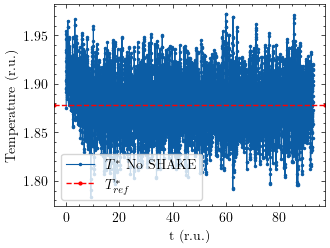

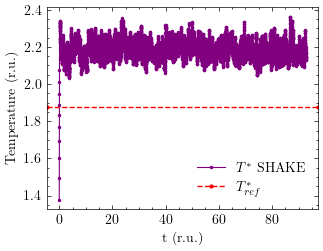

In [ ]:
# No shake
data = np.loadtxt('../out/energies_T.dat', comments='#')
t     = data[:, 0]
Upot  = data[:, 1]
Kin   = data[:, 2]
Etot  = data[:, 3]
Temp  = data[:, 4]

t_ref = 1.8781302170283807

fig, ax = plt.subplots()
ax.plot(t, Temp, marker='.', markersize=3, linewidth=0.8, label='Temp')
ax.axhline(t_ref, color='red', linewidth=1.0, linestyle='--', label='$T_{ref}$')
ax.set_xlabel('t (r.u.)')
ax.set_ylabel('Temperature (r.u.)')
ax.legend(['$T^*$ No SHAKE', '$T^*_{ref}$'], loc='best', frameon=True)
fig.savefig('../plots/Temperature.pdf', dpi=150, bbox_inches='tight')
plt.show()

# Shake
data_shake = np.loadtxt('../out/energies_T_shake.dat', comments='#')
t_shake     = data_shake[:, 0]
Upot_shake  = data_shake[:, 1]
Kin_shake   = data_shake[:, 2]
Etot_shake  = data_shake[:, 3]
Temp_shake  = data_shake[:, 4]

t_ref_shake = 

fig, ax = plt.subplots()
ax.plot(t_shake, Temp_shake, marker='.', markersize=3, color='purple', linewidth=0.8, label='Temp')
ax.axhline(t_ref_shake, color='red', linewidth=1.0, linestyle='--', label='$T_{ref}$')
ax.set_xlabel('t (r.u.)')
ax.set_ylabel('Temperature (r.u.)')
ax.legend(['$T^*$ SHAKE', '$T^*_{ref}$'], loc='best')
fig.savefig('../plots/Temperature_shake.pdf', dpi=150, bbox_inches='tight')
plt.show()

## Energies

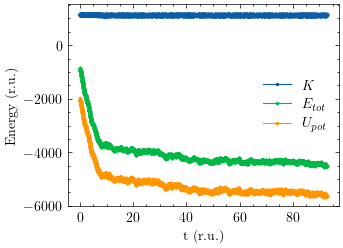

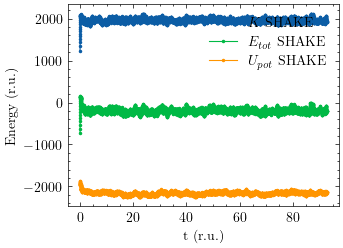

In [3]:
# No shake
fig, ax = plt.subplots()
ax.plot(t, Kin,  marker='.', markersize=3, linewidth=0.8, label='$K$')
ax.plot(t, Etot, marker='.', markersize=3, linewidth=0.8, label='$E_{tot}$')
ax.plot(t, Upot, marker='.', markersize=3, linewidth=0.8, label='$U_{pot}$')
ax.set_xlabel('t (r.u.)')
ax.set_ylabel('Energy (r.u.)')
#ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.15),
          #ncol=3, frameon=True)
ax.legend(loc='best')
fig.savefig('../plots/Energies.pdf', dpi=150, bbox_inches='tight')
plt.show()

# Shake
fig, ax = plt.subplots()
ax.plot(t_shake, Kin_shake,  marker='.', markersize=3, linewidth=0.8, label='$K$ SHAKE')
ax.plot(t_shake, Etot_shake, marker='.', markersize=3, linewidth=0.8, label='$E_{tot}$ SHAKE')
ax.plot(t_shake, Upot_shake, marker='.', markersize=3, linewidth=0.8, label='$U_{pot}$ SHAKE')
ax.set_xlabel('t (r.u.)')
ax.set_ylabel('Energy (r.u.)')
#ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.15),
          #ncol=3, frameon=True)
ax.legend(loc='best')
fig.savefig('../plots/Energies_shake.pdf', dpi=150, bbox_inches='tight')
plt.show()

## Radial Distribution Function $g(r)$

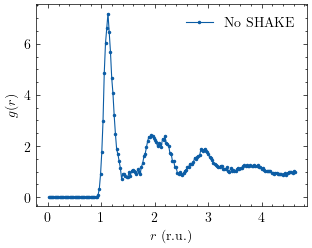

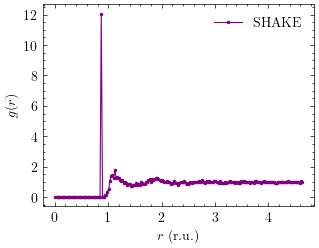

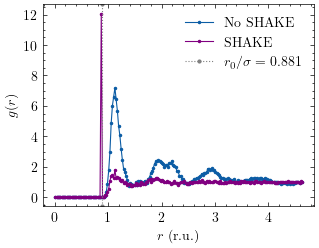

In [4]:
# No shake
rdf = np.loadtxt('../out/gr_ArAr.dat', comments='#')
r   = rdf[:, 0]
gr  = rdf[:, 1]

fig, ax = plt.subplots()
ax.plot(r, gr, marker='.', markersize=3, linewidth=0.8)
ax.set_xlabel('$r$ (r.u.)')
ax.set_ylabel('$g(r)$')
ax.legend(['No SHAKE'], loc='upper right')
fig.savefig('../plots/rdf.pdf', dpi=150, bbox_inches='tight')
plt.show()

# Shake
rdf = np.loadtxt('../out/gr_ArAr_shake.dat', comments='#')
r_shake   = rdf[:, 0]
gr_shake  = rdf[:, 1]

fig, ax = plt.subplots()
ax.plot(r_shake, gr_shake, marker='.', markersize=3, linewidth=0.8, color='purple')
ax.set_xlabel('$r$ (r.u.)')
ax.set_ylabel('$g(r)$')
ax.legend(['SHAKE'], loc='upper right')
fig.savefig('../plots/rdf_shake.pdf', dpi=150, bbox_inches='tight')
plt.show()

# Both
r0_red = 3.0 / 3.405          # intramolecular distance in reduced units (~0.881)
fig, ax = plt.subplots()
ax.plot(r, gr, marker='.', markersize=3, linewidth=0.8)
ax.plot(r_shake, gr_shake, marker='.', markersize=3, linewidth=0.8, color='purple')
ax.axvline(r0_red, color='gray', lw=0.8, ls=':', label=f'$r_0/\\sigma = {r0_red:.3f}$')
ax.set_xlabel('$r$ (r.u.)')
ax.set_ylabel('$g(r) $')
ax.legend(['No SHAKE', 'SHAKE', f'$r_0/\\sigma = {r0_red:.3f}$'], loc='upper right')
fig.savefig('../plots/rdf_both.pdf', dpi=150, bbox_inches='tight')
plt.show()

#### Intermolecular distance check

In [5]:
def read_xyz_traj(filename):
    """Returns list of (N, 3) position arrays, one per frame."""
    frames = []
    with open(filename) as f:
        while True:
            line = f.readline()
            if not line:
                break
            try:
                nat = int(line.strip())
            except ValueError:
                break
            f.readline()  # comment
            pos = []
            for _ in range(nat):
                vals = f.readline().split()
                pos.append([float(v) for v in vals[1:4]])
            frames.append(np.array(pos))
    return frames

frames = read_xyz_traj('../out/trajectory_shake.xyz')
print(f'Frames read: {len(frames)},  atoms/frame: {frames[0].shape[0]}')

Frames read: 1000,  atoms/frame: 600


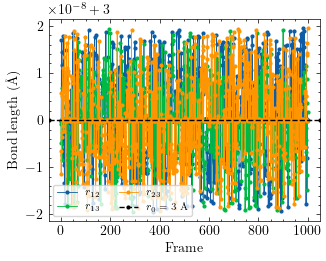

$r_{12}$  mean = 3.000000 Å,  max error = 0.0000 %
$r_{13}$  mean = 3.000000 Å,  max error = 0.0000 %
$r_{23}$  mean = 3.000000 Å,  max error = 0.0000 %


In [6]:
atoms_per_mol = 3
nmol = frames[0].shape[0] // atoms_per_mol
sigma_A = 3.405   # Angstrom – to convert back to Angstrom

pair_idx = [(0,1), (0,2), (1,2)]
pair_labels = ['$r_{12}$', '$r_{13}$', '$r_{23}$']

# Collect distances for ONE representative molecule (mol index 0)
mol = 0
dist_mol = {k: [] for k in pair_labels}

for frame in frames:
    i1 = mol * atoms_per_mol
    for (a, b), lbl in zip(pair_idx, pair_labels):
        dr = frame[i1+a] - frame[i1+b]
        dist_mol[lbl].append(np.linalg.norm(dr) * sigma_A)   # in Angstrom

t_frames = np.arange(len(frames))

fig, ax = plt.subplots()
for lbl in pair_labels:
    ax.plot(t_frames, dist_mol[lbl], lw=0.6, label=lbl)
ax.axhline(3.0, color='k', lw=1.0, ls='--', label='$r_0 = 3$ Å')
ax.set_xlabel('Frame')
ax.set_ylabel('Bond length (Å)')
ax.legend(ncol=2, frameon=True, fontsize=7)
fig.savefig('../plots/bond_lengths_shake.pdf', bbox_inches='tight')
plt.show()

# Print mean and max error
for lbl in pair_labels:
    arr = np.array(dist_mol[lbl])
    err = np.abs(arr - 3.0) / 3.0 * 100
    print(f'{lbl}  mean = {arr.mean():.6f} Å,  max error = {err.max():.4f} %')

## Mean Square Displacement & Diffusion coefficient

Computes the MSD of the centre-of-mass of each molecule for both trajectories
and estimates the self-diffusion coefficient D via the Einstein relation:

$$D = \lim_{t\to\infty} \frac{\langle |\mathbf{r}(t)-\mathbf{r}(0)|^2 \rangle}{6t}$$


In [7]:
def compute_com_traj(frames, atoms_per_mol):
    """Returns (nframes, nmol, 3) array of centre-of-mass positions."""
    nframes = len(frames)
    nmol = frames[0].shape[0] // atoms_per_mol
    com = np.zeros((nframes, nmol, 3))
    for f_idx, frame in enumerate(frames):
        for m in range(nmol):
            i = m * atoms_per_mol
            com[f_idx, m] = frame[i:i+atoms_per_mol].mean(axis=0)
    return com

def msd_from_com(com):
    """Returns MSD array averaged over all molecules."""
    nframes, nmol, _ = com.shape
    msd = np.zeros(nframes)
    for lag in range(nframes):
        disp = com[lag:] - com[:nframes-lag]
        msd[lag] = (disp**2).sum(axis=-1).mean()
    return msd

frames_noshake = read_xyz_traj('../out/trajectory.xyz')
print(f'No-SHAKE frames: {len(frames_noshake)}')
print(f'SHAKE frames:    {len(frames)}')


No-SHAKE frames: 1000
SHAKE frames:    1000


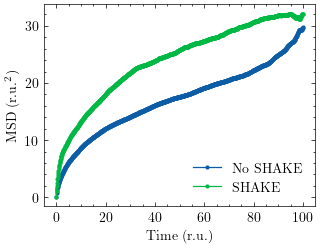

D (no SHAKE) = 0.03542 r.u.
D (SHAKE)    = 0.02225 r.u.


In [8]:
com_ns = compute_com_traj(frames_noshake, atoms_per_mol)
com_s  = compute_com_traj(frames,         atoms_per_mol)

msd_ns = msd_from_com(com_ns)
msd_s  = msd_from_com(com_s)

# time axis: traj_stride=10 (no-shake) and traj_stride=10 (shake), dt reduced
dt_red   = 0.01   # timestep in reduced units
stride   = 10
t_msd_ns = np.arange(len(msd_ns)) * stride * dt_red
t_msd_s  = np.arange(len(msd_s))  * stride * dt_red

fig, ax = plt.subplots()
ax.plot(t_msd_ns, msd_ns, lw=0.9, label='No SHAKE')
ax.plot(t_msd_s,  msd_s,  lw=0.9, label='SHAKE')
ax.set_xlabel('Time (r.u.)')
ax.set_ylabel('MSD (r.u.$^2$)')
ax.legend()
fig.savefig('../plots/MSD.pdf', bbox_inches='tight')
plt.show()

# Linear fit on the second half to estimate D
def diffusion_coeff(t, msd):
    half = len(t) // 2
    coeffs = np.polyfit(t[half:], msd[half:], 1)
    return coeffs[0] / 6.0   # D = slope / 6  (3D)

D_ns = diffusion_coeff(t_msd_ns, msd_ns)
D_s  = diffusion_coeff(t_msd_s,  msd_s)
print(f'D (no SHAKE) = {D_ns:.5f} r.u.')
print(f'D (SHAKE)    = {D_s:.5f} r.u.')